# Task 8: Finding LG Steady State

## Importing Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

## Defining helper functions for the simulation

In [2]:
def plt_sim(t, y):
    plt.plot(t, y[:, 0], label="Prey")
    plt.plot(t, y[:, 1], label="Predator")
    plt.legend()
    plt.ylabel("Populations Size")
    plt.xlabel("Time")
    plt.show()
    
def logistic_func(y0, t, alpha, beta, delta, gamma, k):
    dxdt = (alpha * y0[0]*(1 - y0[0]/k)) - (beta * y0[0] * y0[1])
    dydt = (delta * y0[0] * y0[1]) - (gamma * y0[1])
    return dxdt, dydt
    
def logistic_phase_space_plot(ranges):
    for y0 in ranges:
        y = odeint(logistic_func, y0, t, args=(alpha, beta, delta, gamma, k))
        plt.plot(y[:, 0], y[:, 1], label="y0= " + str(y0))

    # Direction fields creation process from: https://scipy-cookbook.readthedocs.io/items/LoktaVolterraTutorial.html
    # Creating a grid and computing the direction at each point
    nb_points = 20
    ymax = plt.ylim(ymin=0)[1]
    xmax = plt.xlim(xmin=0)[1]
    x = np.linspace(0, xmax, nb_points)
    y = np.linspace(0, ymax, nb_points)
    X1 , Y1  = np.meshgrid(x, y) 
    # Computing growth rate on the grid
    DX1, DY1 = logistic_func([X1, Y1], 0, alpha, beta, delta, gamma, k)
    # Norm of the growth rate 
    M = (np.hypot(DX1, DY1))    
    # Avoiding zero division errors 
    M[ M == 0] = 1.0
    # Normalizing the arrows
    DX1 /= M      
    DY1 /= M

    plt.title('Trajectories and direction fields')
    # Drawing direction fields and using different colors to highlight gorwth speed
    Q = plt.quiver(X1, Y1, DX1, DY1, M, pivot='mid', cmap=plt.cm.jet)
    plt.xlabel('Number of Preys')
    plt.ylabel('Number of Predators')
    plt.legend()
    plt.grid()
    plt.xlim(0, xmax)
    plt.ylim(0, ymax)
    plt.show()

## Running the simulation and exploring the results

In [3]:
# Prey, Predator
y0 = [10, 10]
alpha, beta = 0.1, 0.02
delta, gamma = 0.02, 0.4
end_time = 100
n_samples = 1000
t = np.linspace(0, end_time, n_samples)
k = 120

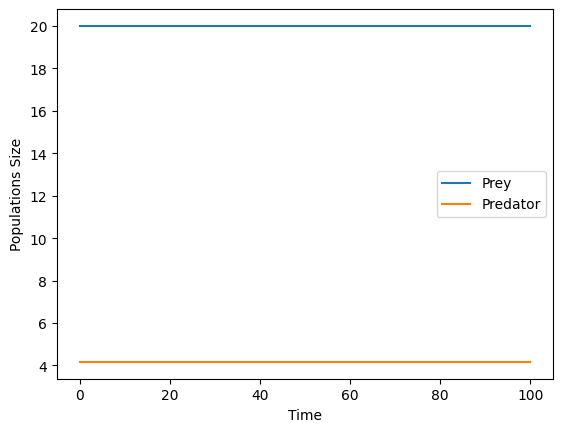

In [4]:
y = odeint(logistic_func, [gamma/delta, alpha/beta*(1-gamma/(delta*k))], t, args=(alpha, beta, delta, gamma, k))
plt_sim(t, y)